In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/cleaned/Saudi_Beverage_Sales_Cleaned.csv")

df.shape

(20000, 17)

In [2]:
df.columns.tolist()

['Order_ID',
 'Date',
 'Region',
 'City',
 'Sales_Channel',
 'Retailer',
 'Brand',
 'Product',
 'Category',
 'Package_Size_ml',
 'Units_Sold',
 'Unit_Price_SAR',
 'Unit_Cost_SAR',
 'Revenue_SAR',
 'Cost_SAR',
 'Profit_SAR',
 'Gross_Margin_Pct']

In [4]:
df["Date"] = pd.to_datetime(df["Date"])

df["Date"].dtype

dtype('<M8[us]')

In [5]:
monthly_plot = (
    df.assign(
        Month=df["Date"].dt.to_period("M").astype(str)
    )
    .groupby("Month")
    .agg(
        Revenue_SAR=("Revenue_SAR", "sum"),
        Profit_SAR=("Profit_SAR", "sum")
    )
)

monthly_plot

,Revenue_SAR,Profit_SAR
Month,,
2025-01,1068259.69,441851.37
2025-02,1003768.31,412995.37
2025-03,1179704.63,488967.97
2025-04,1055530.19,433732.68
2025-05,1127856.60,463211.14
2025-06,1161591.00,484587.64
2025-07,1174065.09,486798.69
2025-08,1083743.76,448074.34
2025-09,860337.74,353243.36


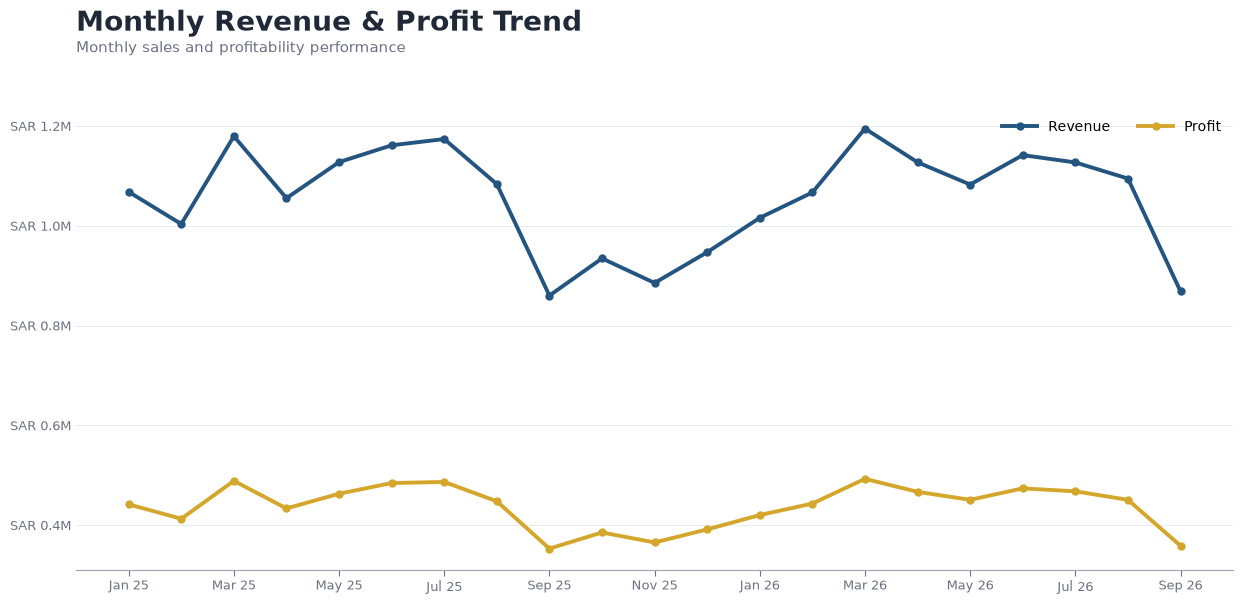

In [11]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Professional font
plt.rcParams["font.family"] = "DejaVu Sans"

fig, ax = plt.subplots(figsize=(13, 7))

# -----------------------------
# Colors
# -----------------------------
revenue_color = "#245580"
profit_color = "#D4A72C"
text_color = "#1F2937"
muted_color = "#6B7280"
grid_color = "#D9DEE5"

# -----------------------------
# Plot lines
# -----------------------------
ax.plot(
    monthly_plot.index,
    monthly_plot["Revenue_SAR"],
    color=revenue_color,
    linewidth=2.8,
    marker="o",
    markersize=5,
    label="Revenue"
)

ax.plot(
    monthly_plot.index,
    monthly_plot["Profit_SAR"],
    color=profit_color,
    linewidth=2.8,
    marker="o",
    markersize=5,
    label="Profit"
)

# -----------------------------
# Header
# -----------------------------
fig.text(
    0.08,
    0.96,
    "Monthly Revenue & Profit Trend",
    fontsize=20,
    fontweight="bold",
    color=text_color,
    ha="left",
    va="top"
)

fig.text(
    0.08,
    0.915,
    "Monthly sales and profitability performance",
    fontsize=10.5,
    color=muted_color,
    ha="left",
    va="top"
)

# -----------------------------
# Y-axis formatting
# -----------------------------
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"SAR {x / 1_000_000:.1f}M")
)

# -----------------------------
# X-axis formatting
# -----------------------------
# Show every second month to reduce crowding
tick_positions = range(0, len(monthly_plot.index), 2)

ax.set_xticks(list(tick_positions))

ax.set_xticklabels(
    [
        pd.to_datetime(monthly_plot.index[i]).strftime("%b %y")
        for i in tick_positions
    ],
    fontsize=9,
    color=muted_color
)

# -----------------------------
# Axis styling
# -----------------------------
ax.set_xlabel("")
ax.set_ylabel("")

ax.tick_params(
    axis="y",
    labelsize=9,
    colors=muted_color,
    length=0
)

ax.tick_params(
    axis="x",
    colors=muted_color,
    length=4
)

# -----------------------------
# Grid
# -----------------------------
ax.grid(
    axis="y",
    linestyle="-",
    linewidth=0.6,
    color=grid_color,
    alpha=0.7
)

ax.grid(
    axis="x",
    visible=False
)

ax.set_axisbelow(True)

# -----------------------------
# Remove unnecessary borders
# -----------------------------
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.spines["bottom"].set_color("#9CA3AF")
ax.spines["bottom"].set_linewidth(0.8)

# -----------------------------
# Legend
# -----------------------------
ax.legend(
    loc="upper right",
    frameon=False,
    ncol=2,
    fontsize=10,
    handlelength=2.5
)

# -----------------------------
# Layout
# -----------------------------
fig.subplots_adjust(
    left=0.08,
    right=0.97,
    top=0.82,
    bottom=0.16
)

# -----------------------------
# Save
# -----------------------------
plt.savefig(
    "../dashboard/screenshots/monthly_revenue_profit_trend.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [7]:
brand_revenue = (
    df.groupby("Brand")["Revenue_SAR"]
      .sum()
      .sort_values(ascending=True)
)

brand_revenue

Brand
Fanta            876387.54
Mountain Dew    1724356.33
Sprite          1840213.56
7UP             2307903.18
Mirinda         3085945.01
Coca-Cola       3638949.32
Kinza           4337895.38
Pepsi           4392484.90
Name: Revenue_SAR, dtype: float64

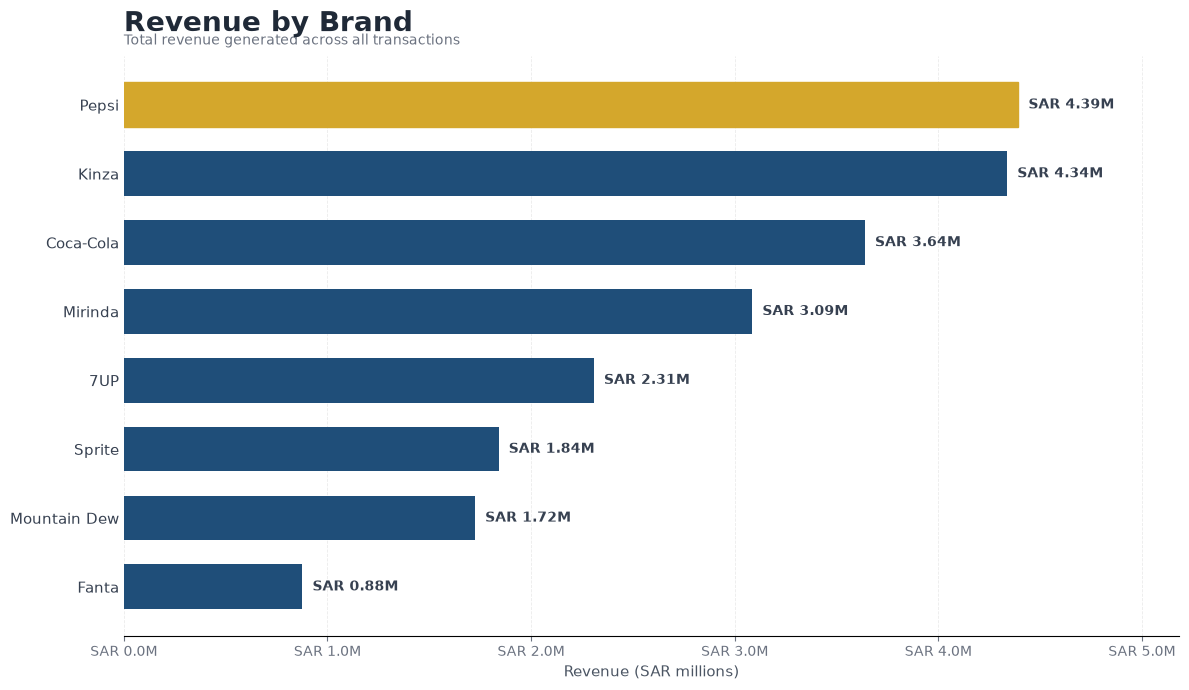

In [9]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(12, 7))

# Sort highest to lowest
brand_revenue_plot = brand_revenue.sort_values(ascending=True)

# Professional color palette
bars = ax.barh(
    brand_revenue_plot.index,
    brand_revenue_plot.values,
    color="#1F4E79",
    height=0.65
)

# Highlight the top-performing brand
bars[-1].set_color("#D4A72C")

# Title
ax.set_title(
    "Revenue by Brand",
    fontsize=20,
    fontweight="bold",
    color="#1F2937",
    loc="left",
    pad=18
)

# Subtitle
ax.text(
    0,
    1.02,
    "Total revenue generated across all transactions",
    transform=ax.transAxes,
    fontsize=10,
    color="#6B7280"
)

# Axis formatting
ax.set_xlabel("Revenue (SAR millions)", fontsize=11, color="#4B5563")
ax.set_ylabel("")

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"SAR {x/1_000_000:.1f}M")
)

# Grid
ax.xaxis.grid(
    True,
    linestyle="--",
    linewidth=0.6,
    alpha=0.25
)

ax.set_axisbelow(True)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# Tick styling
ax.tick_params(
    axis="y",
    length=0,
    labelsize=11,
    colors="#374151"
)

ax.tick_params(
    axis="x",
    labelsize=10,
    colors="#6B7280"
)

# Data labels
for bar in bars:
    value = bar.get_width()

    ax.text(
        value + 50_000,
        bar.get_y() + bar.get_height() / 2,
        f"SAR {value/1_000_000:.2f}M",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="#374151"
    )

# Give labels some breathing room
ax.set_xlim(0, brand_revenue_plot.max() * 1.18)

plt.tight_layout()

plt.savefig(
    "../dashboard/screenshots/revenue_by_brand.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [12]:
brand_profit = (
    df.groupby("Brand")["Profit_SAR"]
      .sum()
      .sort_values(ascending=True)
)

brand_profit

Brand
Fanta            371431.76
Mountain Dew     681167.66
Sprite           778025.99
7UP              977931.00
Mirinda         1335166.40
Coca-Cola       1475637.27
Kinza           1759511.55
Pepsi           1804090.56
Name: Profit_SAR, dtype: float64

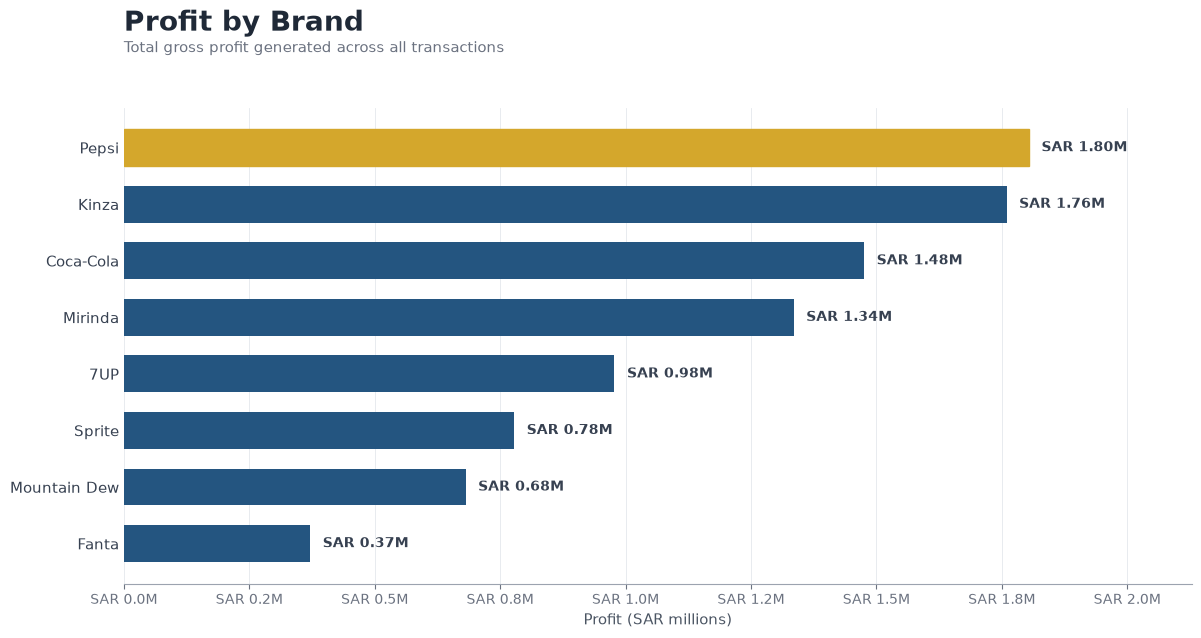

In [13]:
fig, ax = plt.subplots(figsize=(12, 7))

brand_profit_plot = brand_profit.sort_values(ascending=True)

bars = ax.barh(
    brand_profit_plot.index,
    brand_profit_plot.values,
    color="#245580",
    height=0.65
)

bars[-1].set_color("#D4A72C")

fig.text(
    0.08,
    0.96,
    "Profit by Brand",
    fontsize=20,
    fontweight="bold",
    color="#1F2937",
    ha="left",
    va="top"
)

fig.text(
    0.08,
    0.915,
    "Total gross profit generated across all transactions",
    fontsize=10.5,
    color="#6B7280",
    ha="left",
    va="top"
)

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"SAR {x / 1_000_000:.1f}M")
)

ax.set_xlabel(
    "Profit (SAR millions)",
    fontsize=11,
    color="#4B5563"
)

ax.set_ylabel("")

ax.xaxis.grid(
    True,
    linestyle="-",
    linewidth=0.6,
    color="#D9DEE5",
    alpha=0.7
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.spines["bottom"].set_color("#9CA3AF")
ax.spines["bottom"].set_linewidth(0.8)

ax.tick_params(
    axis="y",
    length=0,
    labelsize=11,
    colors="#374151"
)

ax.tick_params(
    axis="x",
    labelsize=10,
    colors="#6B7280"
)

for bar in bars:
    value = bar.get_width()

    ax.text(
        value + 25_000,
        bar.get_y() + bar.get_height() / 2,
        f"SAR {value / 1_000_000:.2f}M",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="#374151"
    )

ax.set_xlim(
    0,
    brand_profit_plot.max() * 1.18
)

fig.subplots_adjust(
    left=0.08,
    right=0.97,
    top=0.82,
    bottom=0.14
)

plt.savefig(
    "../dashboard/screenshots/profit_by_brand.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [14]:
region_revenue = (
    df.groupby("Region")["Revenue_SAR"]
      .sum()
      .sort_values(ascending=True)
)

region_revenue

Region
Tabuk                853153.86
Jazan               1176006.03
Asir                1276812.74
Madinah             1751706.74
Eastern Province    4115549.37
Riyadh              5128618.94
Makkah              7902287.54
Name: Revenue_SAR, dtype: float64

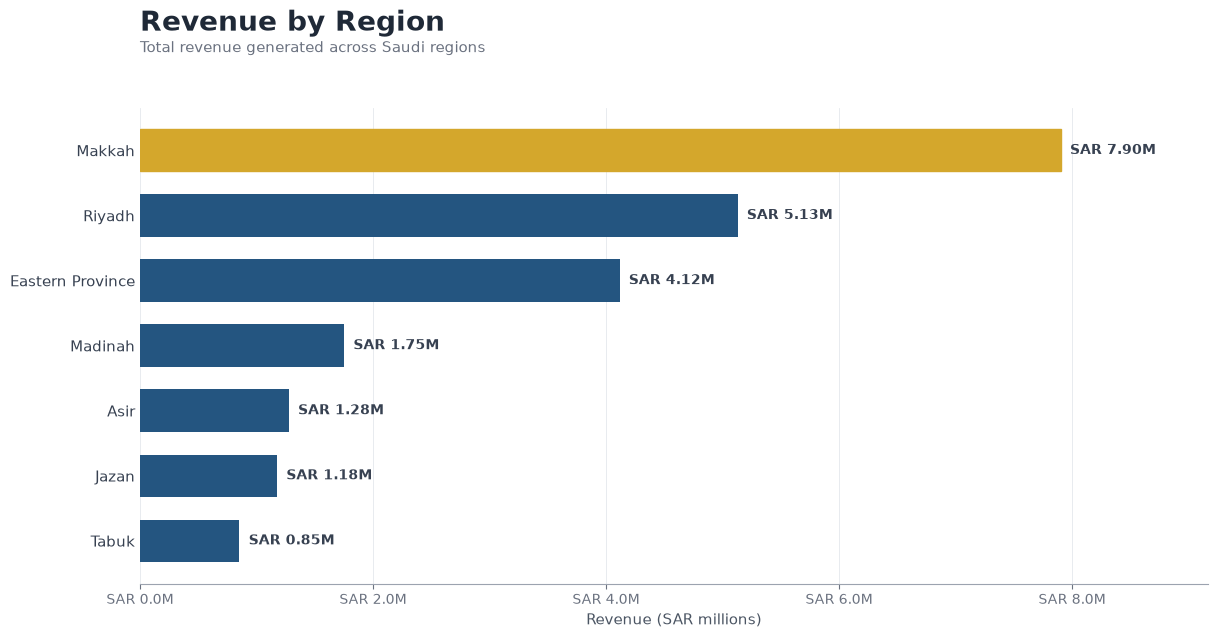

In [15]:
fig, ax = plt.subplots(figsize=(12, 7))

# Sort lowest to highest
region_revenue_plot = region_revenue.sort_values(ascending=True)

# Main bars
bars = ax.barh(
    region_revenue_plot.index,
    region_revenue_plot.values,
    color="#245580",
    height=0.65
)

# Highlight highest-revenue region
bars[-1].set_color("#D4A72C")

# -----------------------------
# Header
# -----------------------------
fig.text(
    0.08,
    0.96,
    "Revenue by Region",
    fontsize=20,
    fontweight="bold",
    color="#1F2937",
    ha="left",
    va="top"
)

fig.text(
    0.08,
    0.915,
    "Total revenue generated across Saudi regions",
    fontsize=10.5,
    color="#6B7280",
    ha="left",
    va="top"
)

# -----------------------------
# X-axis formatting
# -----------------------------
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"SAR {x / 1_000_000:.1f}M")
)

ax.set_xlabel(
    "Revenue (SAR millions)",
    fontsize=11,
    color="#4B5563"
)

ax.set_ylabel("")

# -----------------------------
# Grid
# -----------------------------
ax.xaxis.grid(
    True,
    linestyle="-",
    linewidth=0.6,
    color="#D9DEE5",
    alpha=0.7
)

ax.set_axisbelow(True)

# -----------------------------
# Borders
# -----------------------------
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.spines["bottom"].set_color("#9CA3AF")
ax.spines["bottom"].set_linewidth(0.8)

# -----------------------------
# Tick styling
# -----------------------------
ax.tick_params(
    axis="y",
    length=0,
    labelsize=11,
    colors="#374151"
)

ax.tick_params(
    axis="x",
    labelsize=10,
    colors="#6B7280"
)

# -----------------------------
# Data labels
# -----------------------------
for bar in bars:
    value = bar.get_width()

    ax.text(
        value + 80_000,
        bar.get_y() + bar.get_height() / 2,
        f"SAR {value / 1_000_000:.2f}M",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="#374151"
    )

# Extra room for labels
ax.set_xlim(
    0,
    region_revenue_plot.max() * 1.16
)

# -----------------------------
# Layout
# -----------------------------
fig.subplots_adjust(
    left=0.08,
    right=0.97,
    top=0.82,
    bottom=0.14
)

# -----------------------------
# Save
# -----------------------------
plt.savefig(
    "../dashboard/screenshots/revenue_by_region.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [16]:
channel_revenue = (
    df.groupby("Sales_Channel")["Revenue_SAR"]
      .sum()
      .sort_values(ascending=True)
)

channel_revenue

Sales_Channel
E-commerce           2096646.17
Convenience Store    2685223.79
Hypermarket          5742433.14
Supermarket          5817302.72
Wholesale            5862529.40
Name: Revenue_SAR, dtype: float64

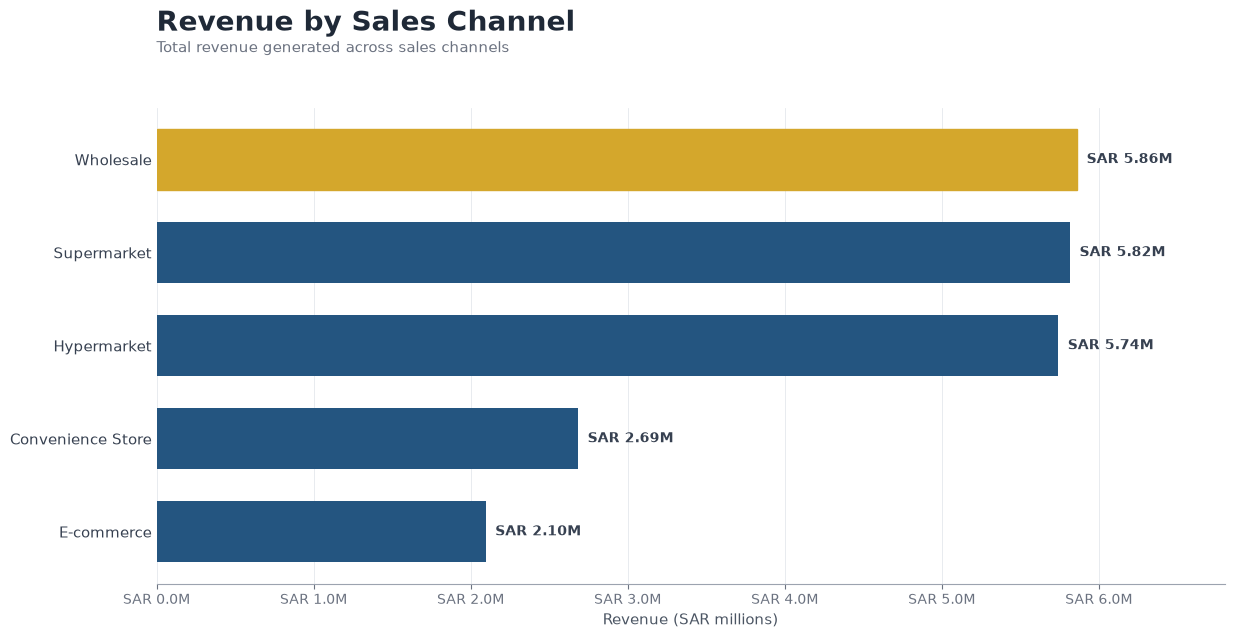

In [17]:
fig, ax = plt.subplots(figsize=(12, 7))

channel_revenue_plot = channel_revenue.sort_values(ascending=True)

# Main bars
bars = ax.barh(
    channel_revenue_plot.index,
    channel_revenue_plot.values,
    color="#245580",
    height=0.65
)

# Highlight highest-revenue channel
bars[-1].set_color("#D4A72C")

# -----------------------------
# Header
# -----------------------------
fig.text(
    0.08,
    0.96,
    "Revenue by Sales Channel",
    fontsize=20,
    fontweight="bold",
    color="#1F2937",
    ha="left",
    va="top"
)

fig.text(
    0.08,
    0.915,
    "Total revenue generated across sales channels",
    fontsize=10.5,
    color="#6B7280",
    ha="left",
    va="top"
)

# -----------------------------
# X-axis formatting
# -----------------------------
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"SAR {x / 1_000_000:.1f}M")
)

ax.set_xlabel(
    "Revenue (SAR millions)",
    fontsize=11,
    color="#4B5563"
)

ax.set_ylabel("")

# -----------------------------
# Grid
# -----------------------------
ax.xaxis.grid(
    True,
    linestyle="-",
    linewidth=0.6,
    color="#D9DEE5",
    alpha=0.7
)

ax.set_axisbelow(True)

# -----------------------------
# Borders
# -----------------------------
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.spines["bottom"].set_color("#9CA3AF")
ax.spines["bottom"].set_linewidth(0.8)

# -----------------------------
# Tick styling
# -----------------------------
ax.tick_params(
    axis="y",
    length=0,
    labelsize=11,
    colors="#374151"
)

ax.tick_params(
    axis="x",
    labelsize=10,
    colors="#6B7280"
)

# -----------------------------
# Data labels
# -----------------------------
for bar in bars:
    value = bar.get_width()

    ax.text(
        value + 60_000,
        bar.get_y() + bar.get_height() / 2,
        f"SAR {value / 1_000_000:.2f}M",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="#374151"
    )

# Extra room for labels
ax.set_xlim(
    0,
    channel_revenue_plot.max() * 1.16
)

# -----------------------------
# Layout
# -----------------------------
fig.subplots_adjust(
    left=0.08,
    right=0.97,
    top=0.82,
    bottom=0.14
)

# -----------------------------
# Save
# -----------------------------
plt.savefig(
    "../dashboard/screenshots/revenue_by_sales_channel.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [18]:
brand_margin = (
    df.groupby("Brand")
      .agg(
          Revenue_SAR=("Revenue_SAR", "sum"),
          Profit_SAR=("Profit_SAR", "sum")
      )
)

brand_margin["Gross_Margin_Pct"] = (
    brand_margin["Profit_SAR"] /
    brand_margin["Revenue_SAR"] * 100
)

brand_margin = brand_margin["Gross_Margin_Pct"].sort_values()

brand_margin

Brand
Mountain Dew    39.502720
Coca-Cola       40.551190
Kinza           40.561410
Pepsi           41.072209
Sprite          42.279114
7UP             42.373138
Fanta           42.382136
Mirinda         43.266046
Name: Gross_Margin_Pct, dtype: float64

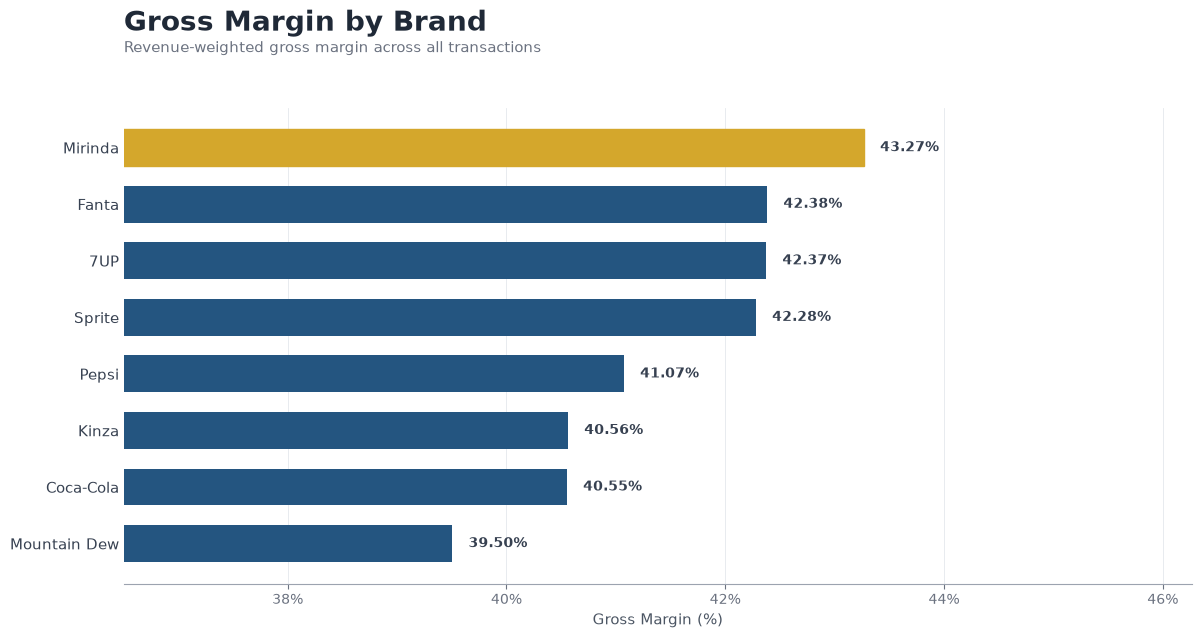

In [19]:
fig, ax = plt.subplots(figsize=(12, 7))

brand_margin_plot = brand_margin.sort_values(ascending=True)

# Main bars
bars = ax.barh(
    brand_margin_plot.index,
    brand_margin_plot.values,
    color="#245580",
    height=0.65
)

# Highlight highest-margin brand
bars[-1].set_color("#D4A72C")

# -----------------------------
# Header
# -----------------------------
fig.text(
    0.08,
    0.96,
    "Gross Margin by Brand",
    fontsize=20,
    fontweight="bold",
    color="#1F2937",
    ha="left",
    va="top"
)

fig.text(
    0.08,
    0.915,
    "Revenue-weighted gross margin across all transactions",
    fontsize=10.5,
    color="#6B7280",
    ha="left",
    va="top"
)

# -----------------------------
# Axis
# -----------------------------
ax.set_xlabel(
    "Gross Margin (%)",
    fontsize=11,
    color="#4B5563"
)

ax.set_ylabel("")

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:.0f}%")
)

# Start slightly below the minimum so differences remain visible
ax.set_xlim(
    max(0, brand_margin_plot.min() - 3),
    brand_margin_plot.max() + 3
)

# -----------------------------
# Grid
# -----------------------------
ax.xaxis.grid(
    True,
    linestyle="-",
    linewidth=0.6,
    color="#D9DEE5",
    alpha=0.7
)

ax.set_axisbelow(True)

# -----------------------------
# Borders
# -----------------------------
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.spines["bottom"].set_color("#9CA3AF")
ax.spines["bottom"].set_linewidth(0.8)

# -----------------------------
# Tick styling
# -----------------------------
ax.tick_params(
    axis="y",
    length=0,
    labelsize=11,
    colors="#374151"
)

ax.tick_params(
    axis="x",
    labelsize=10,
    colors="#6B7280"
)

# -----------------------------
# Data labels
# -----------------------------
for bar in bars:
    value = bar.get_width()

    ax.text(
        value + 0.15,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="#374151"
    )

# -----------------------------
# Layout
# -----------------------------
fig.subplots_adjust(
    left=0.08,
    right=0.97,
    top=0.82,
    bottom=0.14
)

# -----------------------------
# Save
# -----------------------------
plt.savefig(
    "../dashboard/screenshots/gross_margin_by_brand.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [20]:
kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Revenue (SAR)",
        "Total Profit (SAR)",
        "Total Units Sold",
        "Total Transactions",
        "Overall Gross Margin (%)"
    ],
    "Value": [
        df["Revenue_SAR"].sum(),
        df["Profit_SAR"].sum(),
        df["Units_Sold"].sum(),
        df["Order_ID"].nunique(),
        (
            df["Profit_SAR"].sum()
            / df["Revenue_SAR"].sum()
            * 100
        )
    ]
})

kpi_summary

,Metric,Value
0,Total Revenue (SAR),2.220414e+07
1,Total Profit (SAR),9.182962e+06
2,Total Units Sold,8.359569e+06
3,Total Transactions,2.000000e+04
4,Overall Gross Margin (%),4.135699e+01


In [21]:
total_revenue = df["Revenue_SAR"].sum()
total_profit = df["Profit_SAR"].sum()
total_units = df["Units_Sold"].sum()
total_transactions = df["Order_ID"].nunique()

overall_margin = (
    total_profit / total_revenue
) * 100

print(f"Total Revenue: SAR {total_revenue:,.2f}")
print(f"Total Profit: SAR {total_profit:,.2f}")
print(f"Total Units Sold: {total_units:,}")
print(f"Total Transactions: {total_transactions:,}")
print(f"Overall Gross Margin: {overall_margin:.2f}%")

Total Revenue: SAR 22,204,135.22
Total Profit: SAR 9,182,962.19
Total Units Sold: 8,359,569
Total Transactions: 20,000
Overall Gross Margin: 41.36%
